<a href="https://colab.research.google.com/github/aj11anuj/optimly/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Logistic Regression was selected as an interpretable baseline, while LightGBM was chosen to capture nonlinear relationships. Both models predict the underperformer label and are compared with the W04 rule score.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

The data was split 80/20 into training and test sets, using stratification to preserve the target distribution. This random row level split does not guarantee generalization to unseen clients or future periods.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [9]:
!pip -q install duckdb pandas huggingface_hub

In [15]:
import duckdb
import pandas as pd
import numpy as np

PARQUET_PATH = "/content/data_0.parquet"
OUTPUT_PATH = "/content/w05_model_data.csv"

con = duckdb.connect()

query = f"""
WITH items AS (
    SELECT
        client_hash_id,
        content_hash_id,

        -- GSC search performance
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_sum_position) * 1.0
            / NULLIF(SUM(gsc_impressions), 0) AS avg_position,

        SUM(gsc_clicks) * 1.0
            / NULLIF(SUM(gsc_impressions), 0) AS actual_ctr,

        -- Availability and client context
        MAX(CAST(client_has_gsc AS INTEGER)) AS client_has_gsc,
        MAX(CAST(client_has_ga4 AS INTEGER)) AS client_has_ga4,
        MAX(CAST(gsc_data_available AS INTEGER)) AS gsc_data_available,
        MAX(CAST(ga4_data_available AS INTEGER)) AS ga4_data_available,

        -- GA4 engagement and traffic
        SUM(ga4_pageviews) AS ga4_pageviews,
        SUM(ga4_sessions) AS ga4_sessions,
        SUM(ga4_users) AS ga4_users,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS ga4_total_engagement_seconds,

        -- Traffic sources
        SUM(sessions_organic) AS sessions_organic,
        SUM(sessions_direct) AS sessions_direct,
        SUM(sessions_referral) AS sessions_referral,
        SUM(sessions_social) AS sessions_social,
        SUM(sessions_paid) AS sessions_paid,
        SUM(sessions_ai) AS sessions_ai,

        -- AI referral sources
        SUM(ai_chatgpt) AS ai_chatgpt,
        SUM(ai_perplexity) AS ai_perplexity,
        SUM(ai_gemini) AS ai_gemini,
        SUM(ai_copilot) AS ai_copilot,
        SUM(ai_claude) AS ai_claude,
        SUM(ai_meta) AS ai_meta

    FROM read_parquet('{PARQUET_PATH}')
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) > 0
),

bucketed AS (
    SELECT *,
        NTILE(4) OVER (ORDER BY avg_position) AS position_bucket
    FROM items
),

peers AS (
    SELECT *,
        (
            SUM(clicks) OVER (PARTITION BY position_bucket) - clicks
        ) * 1.0
        / NULLIF(
            SUM(impressions) OVER (PARTITION BY position_bucket) - impressions,
            0
        ) AS peer_ctr
    FROM bucketed
),

labeled AS (
    SELECT *,
        CASE
            WHEN actual_ctr < peer_ctr THEN 1
            ELSE 0
        END AS underperformer,

        -- W04 rule score: used for comparison, not as a model feature
        impressions * (peer_ctr - actual_ctr) AS w04_baseline_score,

        LN(1.0 + impressions) AS log_impressions

    FROM peers
    WHERE peer_ctr IS NOT NULL
)

SELECT
    client_hash_id,
    content_hash_id,

    -- Target and W04 comparator
    underperformer,
    w04_baseline_score,

    -- Core GSC features
    impressions,
    log_impressions,
    avg_position,
    position_bucket,

    -- Kept for auditing/label transparency; not model predictors
    clicks,
    actual_ctr,
    peer_ctr,

    -- Availability/context features
    client_has_gsc,
    client_has_ga4,
    gsc_data_available,
    ga4_data_available,

    -- GA4 features
    ga4_pageviews,
    ga4_sessions,
    ga4_users,
    ga4_engaged_sessions,
    ga4_total_engagement_seconds,

    -- Traffic-source features
    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    -- AI-referral features
    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta

FROM labeled
"""

df = con.execute(query).df()
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(df):,} rows to {OUTPUT_PATH}")
print("\nTarget distribution:")
print(df["underperformer"].value_counts(normalize=True).sort_index().round(4))
print("\nPosition bucket distribution:")
print(df["position_bucket"].value_counts(normalize=True).sort_index().round(4))
print("\nDataset shape:", df.shape)
display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved 176,738 rows to /content/w05_model_data.csv

Target distribution:
underperformer
0    0.2062
1    0.7938
Name: proportion, dtype: float64

Position bucket distribution:
position_bucket
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64

Dataset shape: (176738, 32)


,client_hash_id,content_hash_id,underperformer,w04_baseline_score,impressions,log_impressions,avg_position,position_bucket,clicks,actual_ctr,...,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta
0,client_23a62021009f63c4,content_25225b69e49411a9,0,-17.347284,4400.0,8.389587,8.178409,3,31.0,0.007045,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,client_73cda7b4e4f265ea,content_ebca888f934d1eee,1,2.267814,1053.0,6.960348,8.178538,3,1.0,0.000950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,client_fef1a8f436438636,content_213f821cd577e45c,1,0.086892,28.0,3.367296,8.178571,3,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,client_62f4a7e64f5e0096,content_5a1e351c122ba1c7,0,-0.273833,234.0,5.459586,8.179487,3,1.0,0.004274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,client_20259bd6705d81d4,content_692dea1aace1a02f,0,-5.661788,1398.0,7.243513,8.179542,3,10.0,0.007153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:

candidate_features = [
    "log_impressions",
    "avg_position",
    "position_bucket",
    "client_has_gsc",
    "client_has_ga4",
    "gsc_data_available",
    "ga4_data_available",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_seconds",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta"
]

# Coverage report
coverage = (
    df[candidate_features]
    .notna()
    .mean()
    .sort_values(ascending=False)
    .rename("non_null_fraction")
    .to_frame()
)
print("Feature coverage:")

display(coverage.round(3))
MIN_COVERAGE = 0.05
features = [
    col for col in candidate_features
    if df[col].notna().mean() >= MIN_COVERAGE
    and df[col].nunique(dropna=True) > 1
]
dropped_features = [col for col in candidate_features if col not in features]

print(f"\nSelected {len(features)} model features:")
print(features)
print("\nExcluded due to low coverage or no variation:")
print(dropped_features)
X = df[features].replace([np.inf, -np.inf], np.nan)
y = df["underperformer"].astype(int)
print("\nModel input shape:", X.shape)
print("Target counts:")
print(y.value_counts())

Feature coverage:


,non_null_fraction
log_impressions,1.000
avg_position,1.000
position_bucket,1.000
client_has_gsc,1.000
client_has_ga4,1.000
gsc_data_available,1.000
ga4_data_available,0.733
ga4_pageviews,0.733
ga4_sessions,0.733
ga4_users,0.733



Selected 21 model features:
['log_impressions', 'avg_position', 'position_bucket', 'client_has_ga4', 'ga4_data_available', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_seconds', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude']

Excluded due to low coverage or no variation:
['client_has_gsc', 'gsc_data_available', 'ai_meta']

Model input shape: (176738, 21)
Target counts:
underperformer
1    140295
0     36443
Name: count, dtype: int64


In [17]:
!pip -q install lightgbm

import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True),
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=15,
        max_depth=5,
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    )
}
results = []
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = (pred, prob)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC (Average Precision)": average_precision_score(y_test, prob)
    })
w04_score = df.loc[idx_test, "w04_baseline_score"].fillna(0)

results.append({
    "Model": "W04 Rule Score",
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1": np.nan,
    "ROC-AUC": roc_auc_score(y_test, w04_score),
    "PR-AUC (Average Precision)": average_precision_score(y_test, w04_score)
})
results_df = pd.DataFrame(results).set_index("Model")
print("\nModel and W04 baseline comparison:")
display(results_df.round(4))

# Detailed model reports
for name, (pred, prob) in predictions.items():
    print(f"\n{'=' * 55}")
    print(name)
    print("=" * 55)
    print("\nClassification report:")
    print(classification_report(y_test, pred, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))

# Logistic Regression coefficients
lr = models["Logistic Regression"]
transformed_names = (
    lr.named_steps["simpleimputer"]
    .get_feature_names_out(features)
)
lr_importance = pd.DataFrame({
    "Feature": transformed_names,
    "Coefficient": lr.named_steps["logisticregression"].coef_[0]
})
lr_importance["Abs_Coefficient"] = lr_importance["Coefficient"].abs()
lr_importance = lr_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
).drop(columns="Abs_Coefficient")
print("\nLogistic Regression coefficients:")
display(lr_importance.round(4))

# LightGBM feature importance
lgbm_importance = pd.DataFrame({
    "Feature": features,
    "Importance": models["LightGBM"].feature_importances_
}).sort_values("Importance", ascending=False)
print("\nLightGBM feature importance:")
display(lgbm_importance)

test_results = df.loc[idx_test, [
    "client_hash_id",
    "content_hash_id",
    "underperformer",
    "w04_baseline_score",
    "impressions",
    "avg_position",
    "position_bucket",
    "actual_ctr",
    "peer_ctr"
]].copy()

for name, (pred, prob) in predictions.items():
    prefix = name.lower().replace(" ", "_")
    test_results[f"{prefix}_prediction"] = pred
    test_results[f"{prefix}_probability"] = prob

test_results.to_csv("/content/w05_test_predictions.csv", index=False)
results_df.to_csv("/content/w05_model_comparison.csv")
lr_importance.to_csv("/content/w05_logistic_coefficients.csv", index=False)
lgbm_importance.to_csv("/content/w05_lightgbm_importance.csv", index=False)

print("\nSaved:")
print("/content/w05_test_predictions.csv")
print("/content/w05_model_comparison.csv")
print("/content/w05_logistic_coefficients.csv")
print("/content/w05_lightgbm_importance.csv")


Training Logistic Regression...

Training LightGBM...

Model and W04 baseline comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC (Average Precision)
Model,,,,,,
Logistic Regression,0.7182,0.9180,0.7083,0.7996,0.8033,0.9372
LightGBM,0.8240,0.9395,0.8318,0.8824,0.9019,0.9687
W04 Rule Score,NaN,NaN,NaN,NaN,1.0000,1.0000



Logistic Regression

Classification report:
              precision    recall  f1-score   support

           0       0.40      0.76      0.53      7289
           1       0.92      0.71      0.80     28059

    accuracy                           0.72     35348
   macro avg       0.66      0.73      0.66     35348
weighted avg       0.81      0.72      0.74     35348

Confusion matrix:
[[ 5514  1775]
 [ 8186 19873]]

LightGBM

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.79      0.65      7289
           1       0.94      0.83      0.88     28059

    accuracy                           0.82     35348
   macro avg       0.75      0.81      0.77     35348
weighted avg       0.86      0.82      0.83     35348

Confusion matrix:
[[ 5786  1503]
 [ 4719 23340]]

Logistic Regression coefficients:


,Feature,Coefficient
10,sessions_organic,-1.9882
4,ga4_data_available,-0.7096
1,avg_position,0.4772
0,log_impressions,-0.4387
11,sessions_direct,0.2464
2,position_bucket,-0.1479
7,ga4_users,0.1339
5,ga4_pageviews,-0.1159
8,ga4_engaged_sessions,-0.1120
18,ai_gemini,0.0818



LightGBM feature importance:


,Feature,Importance
0,log_impressions,1018
10,sessions_organic,603
1,avg_position,516
7,ga4_users,135
9,ga4_total_engagement_seconds,121
2,position_bucket,105
5,ga4_pageviews,92
14,sessions_paid,87
6,ga4_sessions,43
11,sessions_direct,31



Saved:
/content/w05_test_predictions.csv
/content/w05_model_comparison.csv
/content/w05_logistic_coefficients.csv
/content/w05_lightgbm_importance.csv


In [14]:
import pandas as pd

df = pd.read_csv("/content/w05_model_data.csv")

print("Rows in CSV:", len(df))
print("Columns:", len(df.columns))
print(df["underperformer"].value_counts(dropna=False))

Rows in CSV: 99997
Columns: 32
underperformer
1    79379
0    20618
Name: count, dtype: int64


In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Check whether the W04 score agrees with the target
df["w04_predicted"] = (df["w04_baseline_score"] > 0).astype(int)

mismatches = (df["w04_predicted"] != df["underperformer"]).sum()
print("W04 BASELINE CHECK")
print("-" * 40)
print(f"Total records: {len(df):,}")
print(f"Target/score mismatches: {mismatches:,}")
print(f"Agreement: {(1 - mismatches / len(df)):.2%}")
print("\nW04 rule classification report:")
print(classification_report(
    df["underperformer"],
    df["w04_predicted"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(df["underperformer"], df["w04_predicted"]))

# 3. Review the 10 highest-scoring items
review_cols = [
    "client_hash_id",
    "content_hash_id",
    "impressions",
    "avg_position",
    "actual_ctr",
    "peer_ctr",
    "w04_baseline_score",
    "underperformer"
]

top10 = (
    df.nlargest(10, "w04_baseline_score")[review_cols]
    .copy()
)

top10["action"] = "REVIEW_SNIPPET"
top10["reason_code"] = "CTR_BELOW_POSITION_BASELINE"

print("\nTop 10 W04 items for review:")
display(top10)

W04 BASELINE CHECK
----------------------------------------
Total records: 176,738
Target/score mismatches: 0
Agreement: 100.00%

W04 rule classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36443
           1       1.00      1.00      1.00    140295

    accuracy                           1.00    176738
   macro avg       1.00      1.00      1.00    176738
weighted avg       1.00      1.00      1.00    176738

Confusion matrix:
[[ 36443      0]
 [     0 140295]]

Top 10 W04 items for review:


,client_hash_id,content_hash_id,impressions,avg_position,actual_ctr,peer_ctr,w04_baseline_score,underperformer,action,reason_code
90452,client_23a62021009f63c4,content_44f34c0a90047651,212404.0,0.665877,0.000113,0.003657,752.791502,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
115418,client_73cda7b4e4f265ea,content_8e1334d6356668e3,134984.0,2.693038,0.000007,0.003655,492.348120,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
125198,client_62f4a7e64f5e0096,content_34a70fea29d15f24,143019.0,3.166132,0.000301,0.003655,479.699127,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
111124,client_e547b89c05043229,content_8d7d99f109e19aa2,203497.0,2.468557,0.001420,0.003655,454.686764,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
89942,client_73cda7b4e4f265ea,content_fec55986a1868d62,124075.0,0.308426,0.000008,0.003655,452.433897,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
131839,client_62f4a7e64f5e0096,content_acbcc847f8996314,170808.0,3.396293,0.001534,0.003654,362.085353,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
164442,client_62f4a7e64f5e0096,content_b99ea6861864dea5,194337.0,4.551516,0.001858,0.003654,349.031646,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
21937,client_62f4a7e64f5e0096,content_f6116743b00afc2d,107584.0,9.735658,0.000139,0.003111,319.646829,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
121914,client_62f4a7e64f5e0096,content_7c6373141eae744a,132593.0,5.948459,0.000626,0.002985,312.821458,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE
89825,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,83834.0,0.116003,0.000012,0.003653,305.264666,1,REVIEW_SNIPPET,CTR_BELOW_POSITION_BASELINE


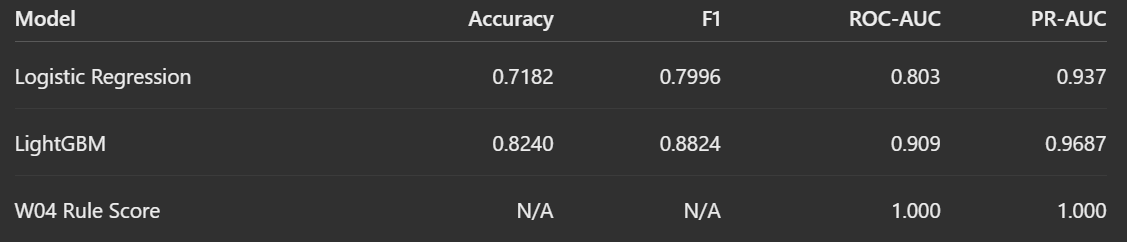

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

LightGBM outperformed Logistic Regression on the held out test set. However, false positives may cause unnecessary reviews, while false negatives may miss underperforming content.

The W04 check showed 100% agreement across 176,738 records, confirming rule consistency. Its perfect ROC-AUC and PR-AUC are not independent evidence, since the target is derived from the same rule. The models used an 80/20 stratified random split. This preserves class proportions but may place related client or content records in both sets. Since no time-based validation was performed, future-period performance remains unverified.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.